In [1]:
# Allow imports from src folder
import sys, os
sys.path.append(os.path.abspath("../src"))

# Data & ML libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: prettier plots
sns.set(style="whitegrid")



In [2]:
# Build path dynamically relative to notebook
project_root = os.path.abspath(os.path.join(".."))  # one level up from notebooks/
data_path = os.path.join(project_root, "data", "synthetic_schools.csv")

# Check file exists
assert os.path.exists(data_path), f"CSV not found at {data_path}"

# Load CSV
df = pd.read_csv(data_path)

# Drop duplicates and handle missing values
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

# Check first few rows
df.head()


,school_id,school_name,avg_sat,avg_act,graduation_rate,acceptance_rate,student_faculty_ratio,tuition_cost,avg_aid,student_population,international_percentage,latitude,longitude,type,urban_rural,ranking
0,SCH001,School_1,1002,33,79,11,16.1,8380,17087,2431,19,45.429481,-103.488970,Private,Suburban,132
1,SCH002,School_2,1335,29,99,22,18.0,13711,8133,4219,10,46.653581,-112.144339,Public,Urban,93
2,SCH003,School_3,1170,31,94,49,21.6,13782,16958,3062,15,30.922612,-66.705878,Private,Urban,379
3,SCH004,School_4,1006,23,54,11,9.1,22434,5704,2179,30,48.588037,-98.213904,Charter,Rural,73
4,SCH005,School_5,971,23,82,74,5.2,25017,27808,736,5,27.517788,-84.391820,Public,Rural,411


In [3]:
# Columns to use for similarity & clustering
feature_cols = ['avg_sat','avg_act','graduation_rate','acceptance_rate',
                'student_faculty_ratio','tuition_cost','avg_aid','student_population',
                'international_percentage','latitude','longitude','ranking']

# Scale numeric features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

# Clip extreme values to avoid t-SNE warnings
scaled_features = np.clip(scaled_features, -10, 10)

scaled_features.shape


(300, 12)

In [4]:
# KNN using cosine similarity
def knn_similarity(df, features, n_neighbors=5):
    knn_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric='cosine')
    knn_model.fit(features)
    distances, indices = knn_model.kneighbors(features)
    
    # Build a dictionary of top neighbors for each school
    top_neighbors = {}
    for i, school in enumerate(df['school_name']):
        # Skip the first one (itself)
        neighbors = [df['school_name'].iloc[idx] for idx in indices[i][1:]]
        top_neighbors[school] = neighbors
    return top_neighbors

# Compute top 5 similar schools
top_sim_dict = knn_similarity(df, scaled_features, n_neighbors=5)


/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [5]:
school_name = df['school_name'].iloc[0]  # first school
print(f"Top 5 schools similar to '{school_name}':")
for s in top_sim_dict[school_name]:
    print("-", s)



Top 5 schools similar to 'School_1':
- School_111
- School_2
- School_85
- School_267
- School_207


In [9]:
# Example structure (pseudo code)
# df['true_similar'] = [['School B', 'School C'], [...], ...]

def calculate_accuracy(df, top_sim_dict):
    correct = 0
    total = 0
    for i, row in df.iterrows():
        true_list = row.get('true_similar', [])
        predicted = top_sim_dict[row['school_name']]
        correct += len(set(true_list) & set(predicted))
        total += len(true_list)
    return correct / total if total > 0 else None

accuracy = calculate_accuracy(df, top_sim_dict)
print("Top-N similarity accuracy:", accuracy)



Top-N similarity accuracy: None


In [7]:
# Cluster schools
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(scaled_features)

df['cluster'] = labels
df.head()



/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,school_id,school_name,avg_sat,avg_act,graduation_rate,acceptance_rate,student_faculty_ratio,tuition_cost,avg_aid,student_population,international_percentage,latitude,longitude,type,urban_rural,ranking,cluster
0,SCH001,School_1,1002,33,79,11,16.1,8380,17087,2431,19,45.429481,-103.488970,Private,Suburban,132,1
1,SCH002,School_2,1335,29,99,22,18.0,13711,8133,4219,10,46.653581,-112.144339,Public,Urban,93,1
2,SCH003,School_3,1170,31,94,49,21.6,13782,16958,3062,15,30.922612,-66.705878,Private,Urban,379,1
3,SCH004,School_4,1006,23,54,11,9.1,22434,5704,2179,30,48.588037,-98.213904,Charter,Rural,73,2
4,SCH005,School_5,971,23,82,74,5.2,25017,27808,736,5,27.517788,-84.391820,Public,Rural,411,1


/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/jahnavisingh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in 

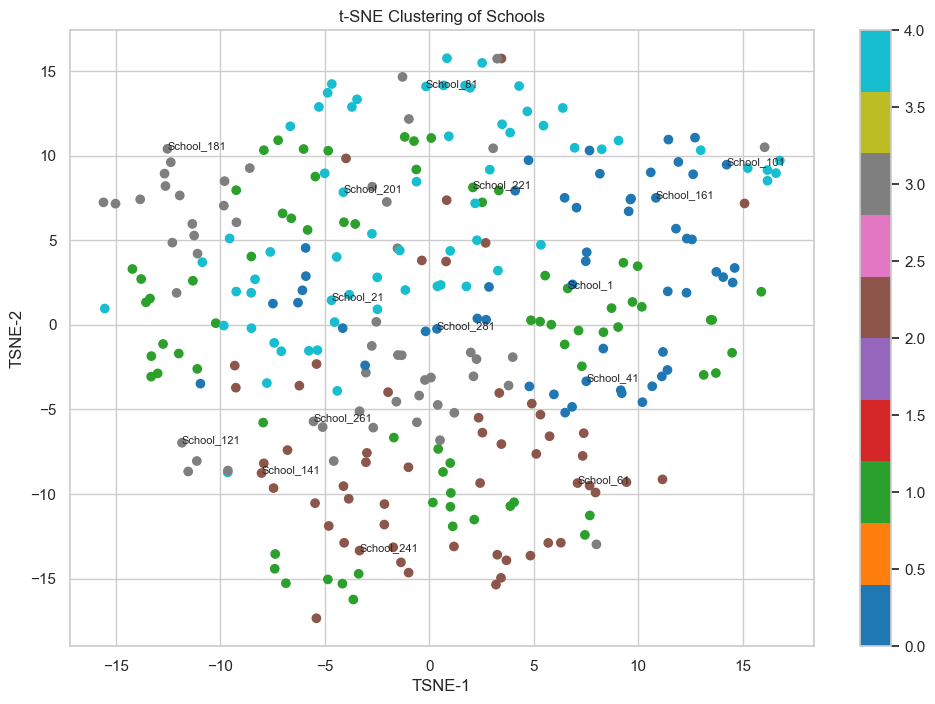

In [8]:
# Reduce dimensions to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

# Plot clusters
plt.figure(figsize=(12,8))
scatter = plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap='tab10')

# Annotate every 20th school
for i, name in enumerate(df['school_name']):
    if i % 20 == 0:
        plt.text(tsne_results[i,0], tsne_results[i,1], name, fontsize=8)

plt.title("t-SNE Clustering of Schools")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter)
plt.show()
